# Dataset description
## Domestic Violence per 100k inhabitants

**Source**: Ministerio de Defensa Nacional

**Download**: [Datos Abiertos](https://www.datos.gov.co/Seguridad-y-Defensa/VIOLENCIA-INTRAFAMILIAR/gepp-dxcs/about_data)

# Code
## Imports

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [21]:
path = "./data/VIOLENCIA_INTRAFAMILIAR_20260809.csv"
pop_path= "./data/nacional.csv"

vio = pd.read_csv(path, encoding="utf-8", usecols=["FECHA HECHO", "DEPARTAMENTO", "CANTIDAD"])
pop = pd.read_csv(pop_path, encoding="utf-8", usecols=["AÑO", "Total"])

## Clean data

In [22]:
vio["FECHA HECHO"] = pd.to_datetime(vio["FECHA HECHO"], dayfirst=True)
vio["FECHA HECHO"] = vio["FECHA HECHO"].dt.year

dept = vio.groupby(["FECHA HECHO", "DEPARTAMENTO"]).sum().reset_index()

year = dept.groupby("FECHA HECHO").sum(numeric_only=True)
year.drop(2026, inplace=True)

national = pd.merge(pop, year, left_on="AÑO", right_index=True, how="inner")
national["Ratio"] = (national["CANTIDAD"] / national["Total"]) * 100000

## Plot

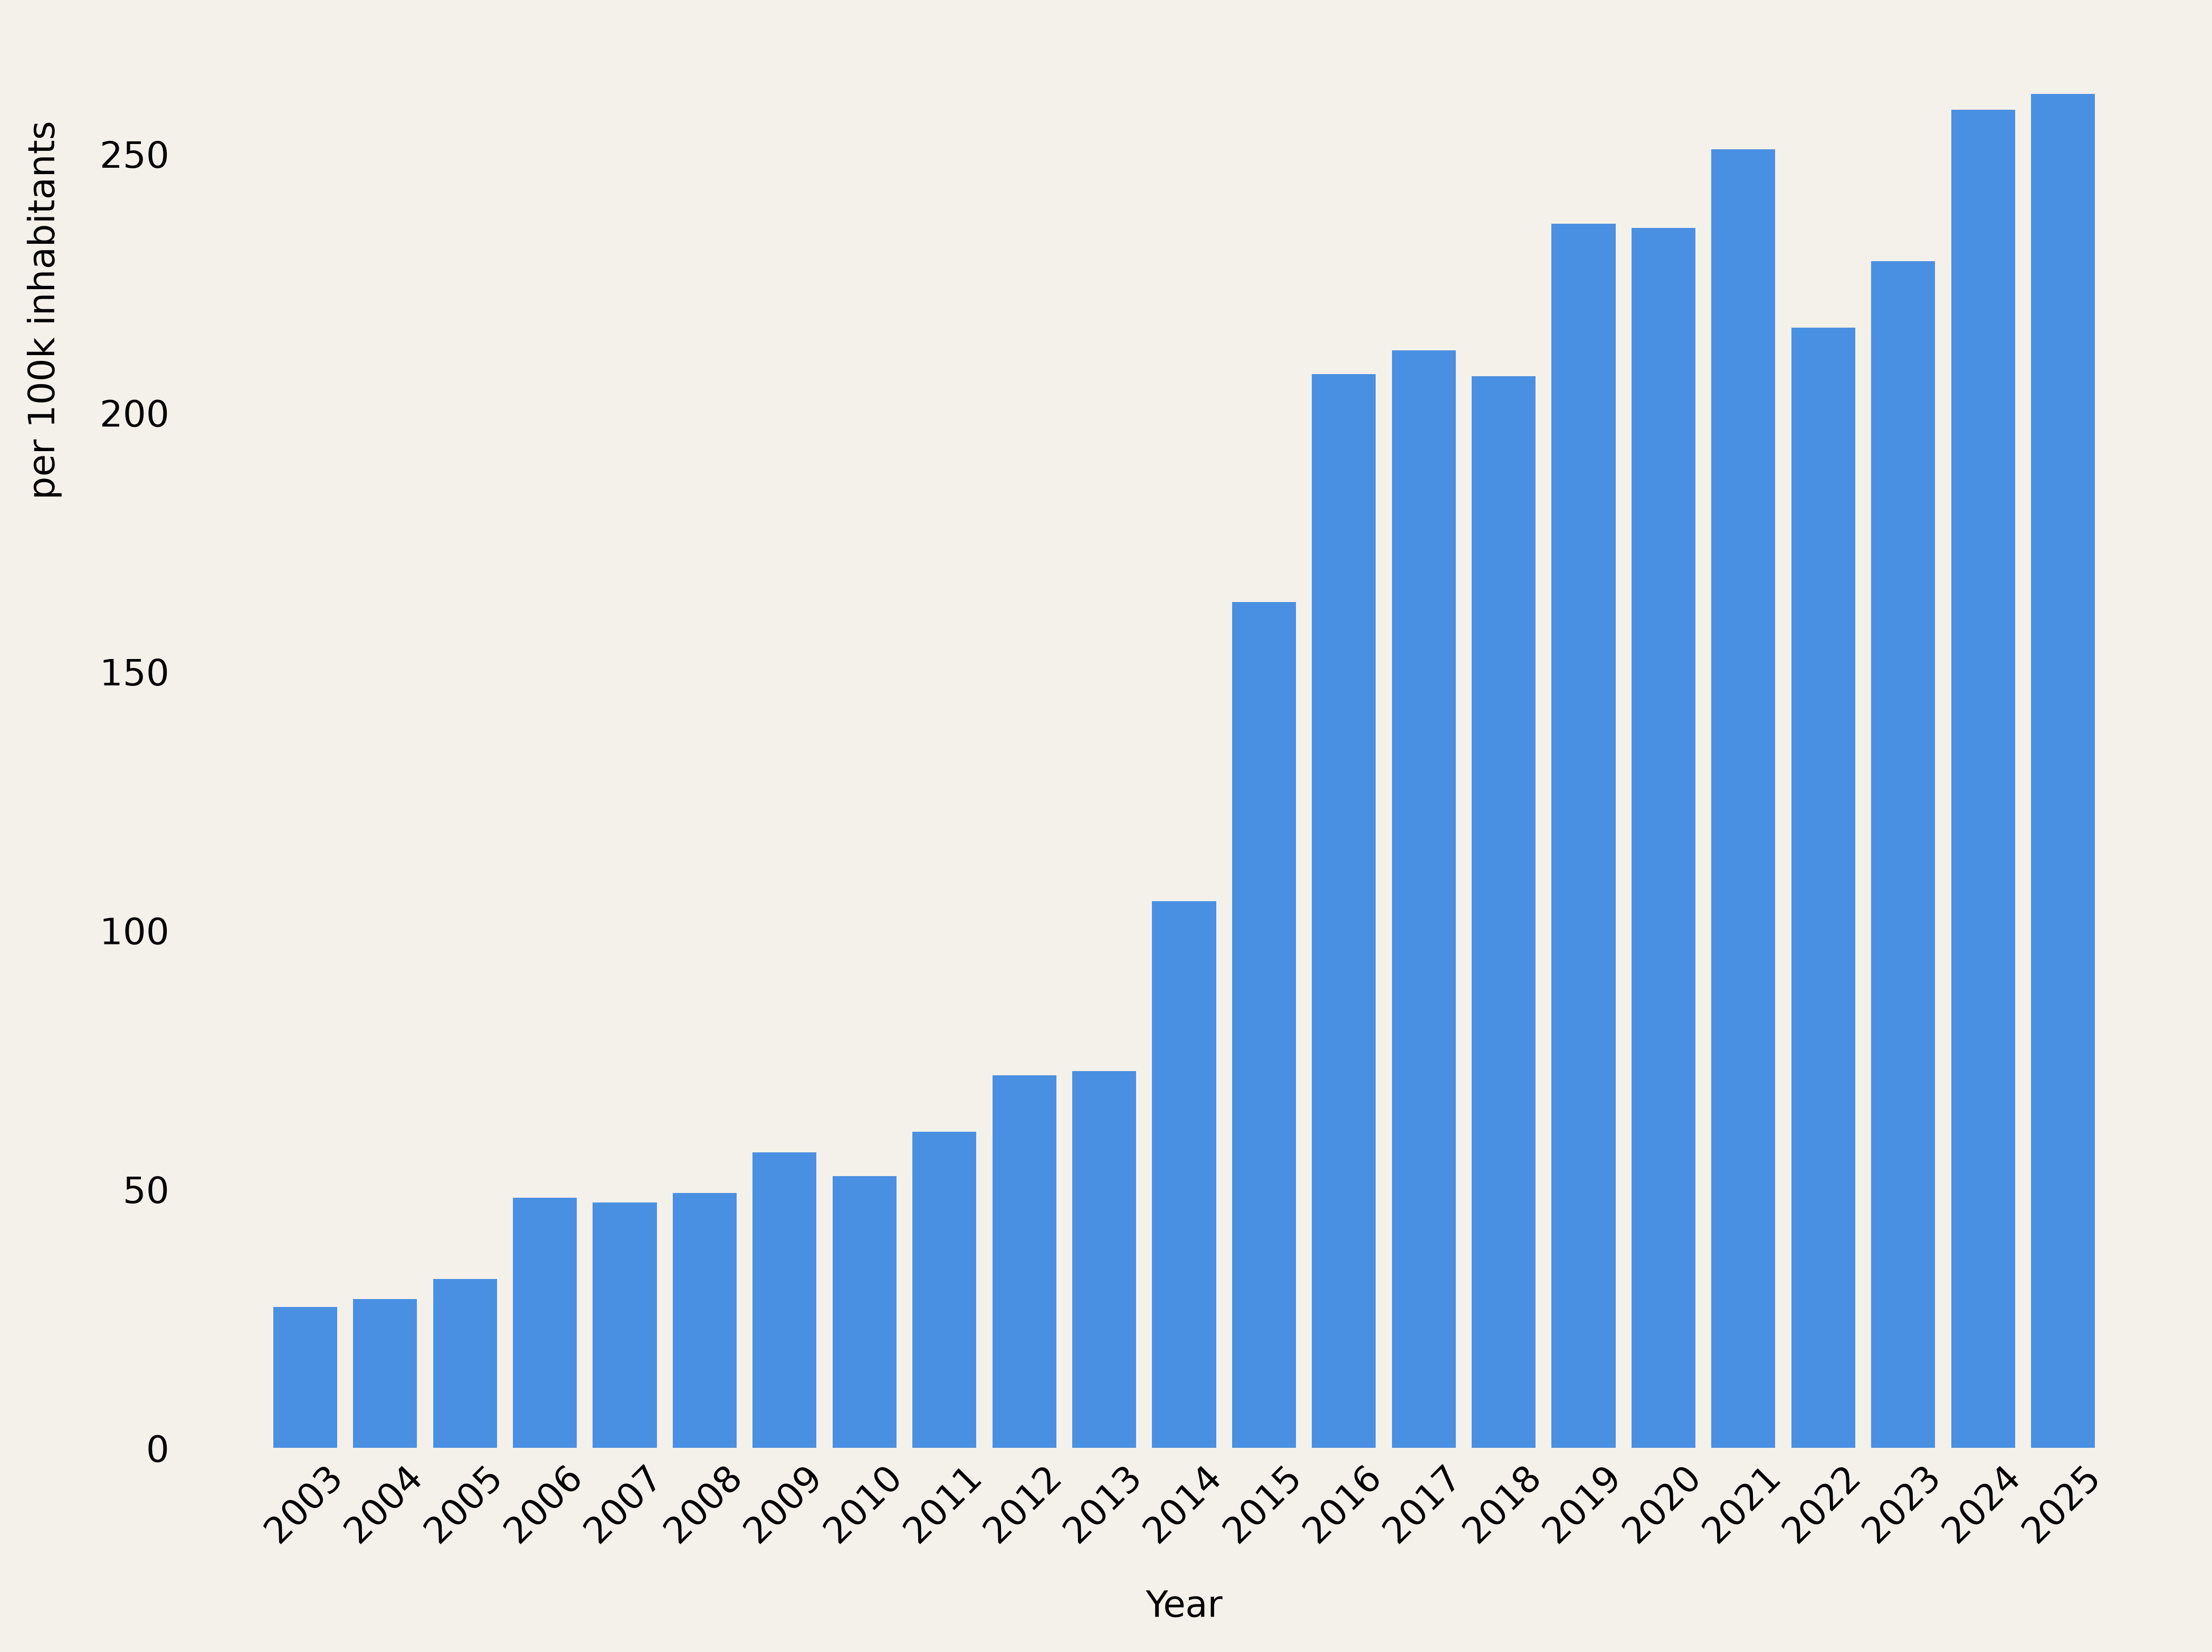

In [32]:
blue = "#4a90e2"
background = "#F4F1EA"

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.bar(national["AÑO"], national["Ratio"], color=blue)

plt.xticks(national["AÑO"], rotation=45)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("per 100k inhabitants", labelpad=10, fontsize=10, y=0.8)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.show()